# Segmentação Semântica em Imagens Histológicas

Esse notebook explora 36 configurações para o dataset núcleos em displasia (`OralEpitheliumDB`), configurado em:

- 3 Combinações de Arquitetura/Modo: Sharp U-Net (FS), U-Net ResNet-18 (FS), U-Net ResNet-18 (PT-ALL)
- 2 Funções de Perda: BCE (`BCEWithLogitsLoss`) vs Dice Loss
- 2 Condições de Augmentation: Sem Augmentation vs Com Augmentation (geométrica sincronizada)
- 3 Seeds: 42, 123, 2025

Totalizando 36 experimentos.

In [ ]:
!pip install -q segmentation-models-pytorch albumentations thop

import os
import gc
import json
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from thop import profile, clever_format

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo em uso: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM Total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.2 MB/s eta 0:00:00
Dispositivo em uso: cuda
GPU: Tesla T4
VRAM Total: 15.64 GB


#### Montagem do Drive e Definição dos Caminhos do Repositório

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/projeto 3/Repositorio'
DATASET_DIR = os.path.join(BASE_DIR, 'datasets/oral_epithelium')
IMAGES_DIR = os.path.join(DATASET_DIR, 'images/Original ROI images')
MASKS_DIR = os.path.join(DATASET_DIR, 'masks/Gold_Standard_Semantic_Segmentation')
SPLITS_CSV = os.path.join(DATASET_DIR, 'splits_displasia.csv')

RESULTS_DIR = os.path.join(BASE_DIR, 'results')
CURVES_DIR = os.path.join(RESULTS_DIR, 'curves_json')
PLOTS_DIR = os.path.join(RESULTS_DIR, 'plots_pdf')
QUALITATIVE_DIR = os.path.join(RESULTS_DIR, 'qualitative')
CHECKPOINTS_DIR = os.path.join(BASE_DIR, 'checkpoints')
CONSOLIDATED_CSV = os.path.join(RESULTS_DIR, 'resultados_displasia.csv')

for d in [RESULTS_DIR, CURVES_DIR, PLOTS_DIR, QUALITATIVE_DIR, CHECKPOINTS_DIR]:
    os.makedirs(d, exist_ok=True)
print('Diretórios verificados!')

Mounted at /content/drive
Diretórios verificados!


#### Configurações de Parametros do Experimento

In [ ]:
SPLIT_SEED = 42
SEEDS = [42, 123, 2025]

INPUT_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 50
LR = 1e-4
PATIENCE = 12  # early stopping

ARCHITECTURES = [
    {'model': 'sharp_unet', 'encoder': 'none', 'training_mode': 'FS'},
    {'model': 'unet_resnet18', 'encoder': 'resnet18', 'training_mode': 'FS'},
    {'model': 'unet_resnet18', 'encoder': 'resnet18', 'training_mode': 'PT-ALL'}
]
LOSSES = ['bce', 'dice']
AUGMENTATIONS = ['sem_aug', 'com_aug']

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SPLIT_SEED)

#### Geração de Splits Sem Vazamento de Lâminas/Pacientes

In [ ]:
def generate_displasia_splits(images_dir, masks_dir, output_csv, seed=42):
    if os.path.exists(output_csv):
        print(f'Arquivo de splits já existe: {output_csv}')
        return pd.read_csv(output_csv)

    categories = sorted(set(os.listdir(images_dir)) & set(os.listdir(masks_dir)))

    records = []
    for category in categories:
        img_dir = os.path.join(images_dir, category)
        mask_dir = os.path.join(masks_dir, category)
        for img_name in sorted(os.listdir(img_dir)):
            if not img_name.lower().endswith('.tif'):
                continue
            base_name = os.path.splitext(img_name)[0]
            mask_name = f'{base_name}.png'
            if not os.path.exists(os.path.join(mask_dir, mask_name)):
                continue
            slide_id = base_name.rsplit('-', 1)[0] if '-' in base_name else base_name
            records.append({'image': os.path.join(category, img_name),
                             'mask': os.path.join(category, mask_name),
                             'slide_id': slide_id})

    df = pd.DataFrame(records)
    unique_slides = df['slide_id'].unique()

    rng = np.random.default_rng(seed)
    rng.shuffle(unique_slides)

    n_total = len(unique_slides)
    n_test = max(1, int(n_total * 0.30))
    n_dev = n_total - n_test
    n_val = max(1, int(n_dev * 0.20))
    n_train = n_dev - n_val

    train_slides = set(unique_slides[:n_train])
    val_slides = set(unique_slides[n_train:n_train + n_val])
    test_slides = set(unique_slides[n_train + n_val:])

    def assign_split(slide):
        if slide in train_slides: return 'train'
        if slide in val_slides: return 'val'
        return 'test'

    df['split'] = df['slide_id'].apply(assign_split)
    df.to_csv(output_csv, index=False)
    print(f'Splits gerados. Distribuição: {df["split"].value_counts().to_dict()}')
    return df

#### Dataset e Transformações de Augmentation Sincronizadas

In [ ]:
class OralEpitheliumDataset(Dataset):
    def __init__(self, df, images_dir, masks_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['image'])
        mask_path = os.path.join(self.masks_dir, row['mask'])

        image = np.array(Image.open(img_path).convert('RGB'))
        mask = np.array(Image.open(mask_path).convert('L'), dtype=np.float32)

        # qualquer anotação de núcleo vira 1, o resto é fundo
        mask = (mask > 0).astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        if not isinstance(mask, torch.Tensor):
            mask = torch.tensor(mask, dtype=torch.float32)
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)

        return image, mask

# normalização fixa do ImageNet
NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD = (0.229, 0.224, 0.225)

def get_transforms(use_augmentation=False, img_size=INPUT_SIZE):
    if use_augmentation:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=NORM_MEAN, std=NORM_STD),
            ToTensorV2()
        ])

#### Verificação Visual das Augmentations (antes de treinar)

Arquivo de splits já existe: /content/drive/MyDrive/projeto 3/Repositorio/datasets/oral_epithelium/splits_displasia.csv


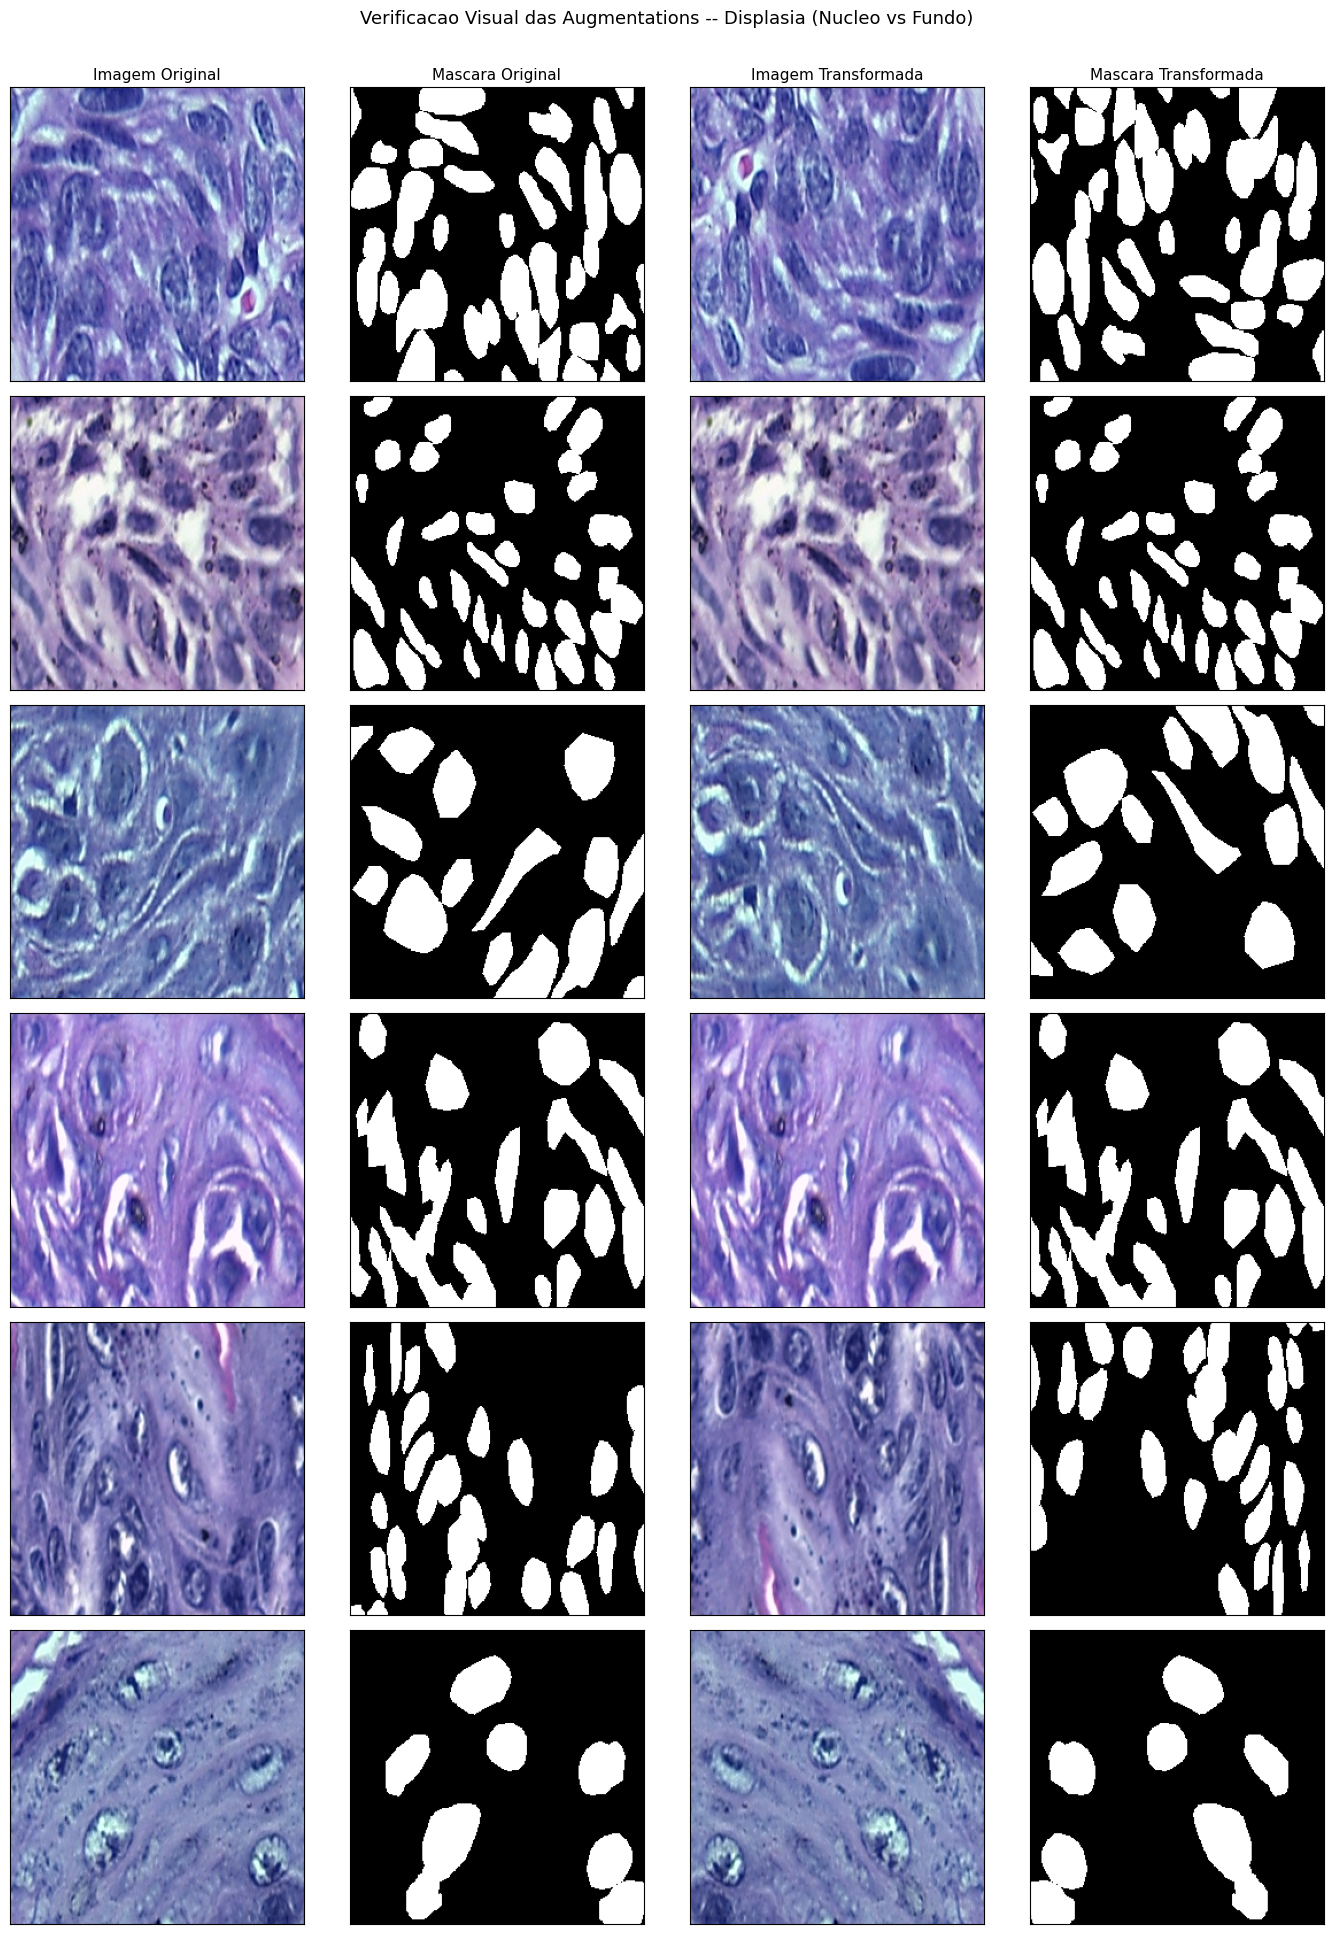

Mascaras permanecem binarias em todas as amostras verificadas: True
Verificacao visual salva em: /content/drive/MyDrive/projeto 3/Repositorio/results/augmentation_check/augmentation_check_displasia.png


In [ ]:
N_AUG_SAMPLES = 6

def get_viz_transform(use_augmentation, img_size=INPUT_SIZE):
    """Mesma pipeline geometrica de get_transforms, mas sem Normalize/ToTensor,
    para permitir visualizacao direta dos pixels"""
    if use_augmentation:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
        ])
    return A.Compose([A.Resize(img_size, img_size)])

df_splits_check = generate_displasia_splits(IMAGES_DIR, MASKS_DIR, SPLITS_CSV, seed=SPLIT_SEED)
train_check_df = df_splits_check[df_splits_check['split'] == 'train'].reset_index(drop=True)

rng_check = np.random.default_rng(SPLIT_SEED)
sample_idxs = rng_check.choice(
    len(train_check_df), size=min(N_AUG_SAMPLES, len(train_check_df)), replace=False
)

viz_resize_only = get_viz_transform(use_augmentation=False)
viz_augmented = get_viz_transform(use_augmentation=True)

fig, axes = plt.subplots(len(sample_idxs), 4, figsize=(14, 3.2 * len(sample_idxs)))
col_titles = ['Imagem Original', 'Mascara Original', 'Imagem Transformada', 'Mascara Transformada']

all_masks_binary = True

for row_i, idx in enumerate(sample_idxs):
    row = train_check_df.iloc[idx]
    img_path = os.path.join(IMAGES_DIR, row['image'])
    mask_path = os.path.join(MASKS_DIR, row['mask'])

    image = np.array(Image.open(img_path).convert('RGB'))
    mask = np.array(Image.open(mask_path).convert('L'), dtype=np.float32)
    mask = (mask > 0).astype(np.float32)  # mesma regra usada no Dataset

    orig = viz_resize_only(image=image, mask=mask)
    aug = viz_augmented(image=image, mask=mask)

    for m in (orig['mask'], aug['mask']):
        if not set(np.unique(m).tolist()).issubset({0.0, 1.0}):
            all_masks_binary = False

    axes[row_i, 0].imshow(orig['image'])
    axes[row_i, 1].imshow(orig['mask'], cmap='gray')
    axes[row_i, 2].imshow(aug['image'])
    axes[row_i, 3].imshow(aug['mask'], cmap='gray')

    for c in range(4):
        axes[row_i, c].set_xticks([])
        axes[row_i, c].set_yticks([])
        if row_i == 0:
            axes[row_i, c].set_title(col_titles[c], fontsize=11)

plt.suptitle('Verificacao Visual das Augmentations -- Displasia (Nucleo vs Fundo)', fontsize=13, y=1.005)
plt.tight_layout()

aug_check_dir = os.path.join(RESULTS_DIR, 'augmentation_check')
os.makedirs(aug_check_dir, exist_ok=True)
save_path = os.path.join(aug_check_dir, 'augmentation_check_displasia.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Mascaras permanecem binarias em todas as amostras verificadas: {all_masks_binary}')
print(f'Verificacao visual salva em: {save_path}')


#### Arquiteturas Sharp U-Net e U-Net com Encoder ResNet-18

In [ ]:
# bloco de sharpening aplicado nas skip connections
class SharpBlock(nn.Module):
    """
    Bloco de sharpening do Sharp U-Net (Zunair & Ben Hamza, 2021)
    """
    def __init__(self, in_channels):
        super(SharpBlock, self).__init__()
        # kernel Laplaciano de 8 vizinhos
        kernel = torch.tensor([[-1., -1., -1.],
                                [-1.,  8., -1.],
                                [-1., -1., -1.]], dtype=torch.float32)
        kernel = kernel.repeat(in_channels, 1, 1, 1)
        # nao é atualizado durante o treinamento
        self.weight = nn.Parameter(kernel, requires_grad=False)
        self.in_channels = in_channels

    def forward(self, x):
        # S = I + K * I (convolucao seguida de soma explicita)
        conv_out = F.conv2d(x, self.weight, padding=1, groups=self.in_channels)
        return x + conv_out


class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)


class SharpUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=1, features=[32, 64, 128, 256]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.sharp_blocks = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        curr_in = in_channels
        for feat in features:
            self.downs.append(ConvBlock(curr_in, feat))
            self.sharp_blocks.append(SharpBlock(feat))
            curr_in = feat

        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        for feat in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feat * 2, feat, kernel_size=2, stride=2))
            self.ups.append(ConvBlock(feat * 2, feat))

        self.final_conv = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for i, down in enumerate(self.downs):
            x = down(x)
            sharp_skip = self.sharp_blocks[i](x)
            skip_connections.append(sharp_skip)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skip_connections[idx // 2]
            if x.shape != skip.shape:
                x = TF.resize(x, size=skip.shape[2:])
            concat_x = torch.cat((skip, x), dim=1)
            x = self.ups[idx + 1](concat_x)

        return self.final_conv(x)


# escolhe qual modelo montar
def build_model(model_name, training_mode, in_channels=3, num_classes=1):
    if model_name == 'sharp_unet':
        return SharpUNet(in_channels=in_channels, num_classes=num_classes)
    elif model_name == 'unet_resnet18':
        weights = 'imagenet' if training_mode == 'PT-ALL' else None
        return smp.Unet(
            encoder_name='resnet18',
            encoder_weights=weights,
            in_channels=in_channels,
            classes=num_classes
        )
    else:
        raise ValueError(f'Modelo desconhecido: {model_name}')

#### Funções de Perda e Métricas de Segmentação

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs = probs.view(-1)
        targets = targets.view(-1)
        intersection = (probs * targets).sum()
        dice = (2.0 * intersection + self.smooth) / (probs.sum() + targets.sum() + self.smooth)
        return 1.0 - dice


def get_loss_function(loss_name):
    if loss_name.lower() == 'bce':
        return nn.BCEWithLogitsLoss()
    elif loss_name.lower() == 'dice':
        return DiceLoss()
    else:
        raise ValueError(f'Loss desconhecida: {loss_name}')


@torch.no_grad()
def calculate_metrics(preds_binary, targets, smooth=1e-6):
    # preds_binary e targets: [B, 1, H, W] binários (0 ou 1)
    p_fg = preds_binary.view(-1)
    t_fg = targets.view(-1)

    p_bg = 1.0 - p_fg
    t_bg = 1.0 - t_fg

    tp_fg = (p_fg * t_fg).sum().item()
    fp_fg = (p_fg * (1.0 - t_fg)).sum().item()
    fn_fg = ((1.0 - p_fg) * t_fg).sum().item()

    dice_fg = (2.0 * tp_fg + smooth) / (2.0 * tp_fg + fp_fg + fn_fg + smooth)
    iou_fg = (tp_fg + smooth) / (tp_fg + fp_fg + fn_fg + smooth)
    prec_fg = (tp_fg + smooth) / (tp_fg + fp_fg + smooth)
    rec_fg = (tp_fg + smooth) / (tp_fg + fn_fg + smooth)

    tp_bg = (p_bg * t_bg).sum().item()
    fp_bg = (p_bg * (1.0 - t_bg)).sum().item()
    fn_bg = ((1.0 - p_bg) * t_bg).sum().item()

    dice_bg = (2.0 * tp_bg + smooth) / (2.0 * tp_bg + fp_bg + fn_bg + smooth)
    iou_bg = (tp_bg + smooth) / (tp_bg + fp_bg + fn_bg + smooth)

    mDice = (dice_fg + dice_bg) / 2.0
    mIoU = (iou_fg + iou_bg) / 2.0

    return {
        'dice_background': dice_bg,
        'dice_foreground': dice_fg,
        'mDice': mDice,
        'iou_background': iou_bg,
        'iou_foreground': iou_fg,
        'mIoU': mIoU,
        'precision_foreground': prec_fg,
        'recall_foreground': rec_fg
    }

#### Funções de Treino, Validação e Avaliação

In [ ]:
import copy

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_masks = [], []

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(outputs)
        preds_binary = (probs >= 0.5).float()

        all_preds.append(preds_binary.cpu())
        all_masks.append(masks.cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_masks = torch.cat(all_masks, dim=0)

    metrics = calculate_metrics(all_preds, all_masks)
    metrics['loss'] = running_loss / len(loader.dataset)
    return metrics


def profile_model_complexity(model, input_size=(1, 3, 256, 256), device='cpu'):
    model_for_profile = copy.deepcopy(model).to(device).eval()
    dummy_input = torch.randn(input_size).to(device)
    try:
        macs, params = profile(model_for_profile, inputs=(dummy_input,), verbose=False)
        gflops = (macs * 2) / 1e9
    except Exception:
        gflops = 0.0
    del model_for_profile

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params, round(gflops, 3)

#### Execução de Experimento Individual

In [ ]:
def run_single_experiment(cfg, df_splits, images_dir, masks_dir, consolidated_csv, curves_dir, checkpoints_dir, device):
    run_id = f"{cfg['dataset']}_{cfg['model']}_{cfg['training_mode']}_{cfg['loss']}_{cfg['augmentation']}_seed{cfg['seed']}"

    if os.path.exists(consolidated_csv):
        res_df = pd.read_csv(consolidated_csv)
        if 'run_id' in res_df.columns and run_id in res_df['run_id'].values:
            print(f'Run já feita: {run_id} -- pulando')
            return

    print(f'\n--- {run_id} ---')

    set_seed(cfg['seed'])

    use_aug = (cfg['augmentation'] == 'com_aug')
    train_tf = get_transforms(use_augmentation=use_aug, img_size=cfg['input_size'])
    eval_tf = get_transforms(use_augmentation=False, img_size=cfg['input_size'])

    train_df = df_splits[df_splits['split'] == 'train']
    val_df = df_splits[df_splits['split'] == 'val']
    test_df = df_splits[df_splits['split'] == 'test']

    train_ds = OralEpitheliumDataset(train_df, images_dir, masks_dir, transform=train_tf)
    val_ds = OralEpitheliumDataset(val_df, images_dir, masks_dir, transform=eval_tf)
    test_ds = OralEpitheliumDataset(test_df, images_dir, masks_dir, transform=eval_tf)

    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=cfg['batch_size'], shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=cfg['batch_size'], shuffle=False, num_workers=2)

    model = build_model(cfg['model'], cfg['training_mode']).to(device)
    criterion = get_loss_function(cfg['loss'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, verbose=False)

    num_params, trainable_params, gflops = profile_model_complexity(model, (1, 3, cfg['input_size'], cfg['input_size']), device)

    best_val_mDice = -1.0
    best_epoch = 0
    patience_counter = 0
    best_model_path = os.path.join(checkpoints_dir, f'best_{run_id}.pth')

    history = {'train_loss': [], 'val_loss': [], 'val_mDice': [], 'val_mIoU': []}

    for epoch in range(1, cfg['epochs'] + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = eval_epoch(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_mDice'].append(val_metrics['mDice'])
        history['val_mIoU'].append(val_metrics['mIoU'])

        scheduler.step(val_metrics['mDice'])

        # salva o melhor checkpoint pelo mDice de validação
        if val_metrics['mDice'] > best_val_mDice:
            best_val_mDice = val_metrics['mDice']
            best_epoch = epoch
            torch.save(model.state_dict(), best_model_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'Early stopping na época {epoch}. Melhor época: {best_epoch}')
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f'  [Época {epoch:02d}/{cfg["epochs"]}] Train Loss: {train_loss:.4f} | Val Loss: {val_metrics["loss"]:.4f} | Val mDice: {val_metrics["mDice"]:.4f}')

    json_path = os.path.join(curves_dir, f'{run_id}.json')
    with open(json_path, 'w') as f:
        json.dump(history, f, indent=2)

    # recarrega o melhor checkpoint e avalia no teste
    model.load_state_dict(torch.load(best_model_path))
    test_metrics = eval_epoch(model, test_loader, criterion, device)

    result_row = {
        'run_id': run_id,
        'repetition': cfg['seed_idx'],
        'seed': cfg['seed'],
        'dataset': cfg['dataset'],
        'task': cfg['task'],
        'model': cfg['model'],
        'encoder': cfg['encoder'],
        'training_mode': cfg['training_mode'],
        'augmentation': cfg['augmentation'],
        'loss': cfg['loss'],
        'input_size': cfg['input_size'],
        'epochs': cfg['epochs'],
        'batch_size': cfg['batch_size'],
        'dice_background_test': round(test_metrics['dice_background'], 4),
        'dice_foreground_test': round(test_metrics['dice_foreground'], 4),
        'mDice_test': round(test_metrics['mDice'], 4),
        'iou_background_test': round(test_metrics['iou_background'], 4),
        'iou_foreground_test': round(test_metrics['iou_foreground'], 4),
        'mIoU_test': round(test_metrics['mIoU'], 4),
        'precision_foreground_test': round(test_metrics['precision_foreground'], 4),
        'recall_foreground_test': round(test_metrics['recall_foreground'], 4),
        'num_params': num_params,
        'trainable_params': trainable_params,
        'gflops': gflops,
        'best_epoch': best_epoch,
        'val_mDice_best': round(best_val_mDice, 4)
    }

    row_df = pd.DataFrame([result_row])
    if os.path.exists(consolidated_csv):
        row_df.to_csv(consolidated_csv, mode='a', header=False, index=False)
    else:
        row_df.to_csv(consolidated_csv, mode='w', header=True, index=False)

    print(f'Test mDice: {test_metrics["mDice"]:.4f} | Test mIoU: {test_metrics["mIoU"]:.4f}')

    del model, optimizer, train_loader, val_loader, test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

#### Execução

Monta as 36 combinações e roda uma por uma e quem já está no CSV consolidado é pulado.

In [ ]:
df_splits = generate_displasia_splits(IMAGES_DIR, MASKS_DIR, SPLITS_CSV, seed=SPLIT_SEED)

configs_displasia = []
for arch in ARCHITECTURES:
    for loss in LOSSES:
        for aug in AUGMENTATIONS:
            for s_idx, seed in enumerate(SEEDS, 1):
                configs_displasia.append({
                    'dataset': 'displasia',
                    'task': 'nuclei_vs_background',
                    'model': arch['model'],
                    'encoder': arch['encoder'],
                    'training_mode': arch['training_mode'],
                    'loss': loss,
                    'augmentation': aug,
                    'seed': seed,
                    'seed_idx': s_idx,
                    'input_size': INPUT_SIZE,
                    'epochs': EPOCHS,
                    'batch_size': BATCH_SIZE,
                    'lr': LR
                })

print(f'Total de configurações geradas para Displasia: {len(configs_displasia)}')

for cfg in configs_displasia:
    run_single_experiment(cfg, df_splits, IMAGES_DIR, MASKS_DIR, CONSOLIDATED_CSV, CURVES_DIR, CHECKPOINTS_DIR, device)

print('Fim das 36 execuções de Displasia.')

Arquivo de splits já existe: /content/drive/MyDrive/projeto 3/Repositorio/datasets/oral_epithelium/splits_displasia.csv
Total de configurações geradas para Displasia: 36
Run já feita: displasia_sharp_unet_FS_bce_sem_aug_seed42 -- pulando
Run já feita: displasia_sharp_unet_FS_bce_sem_aug_seed123 -- pulando
Run já feita: displasia_sharp_unet_FS_bce_sem_aug_seed2025 -- pulando
Run já feita: displasia_sharp_unet_FS_bce_com_aug_seed42 -- pulando
Run já feita: displasia_sharp_unet_FS_bce_com_aug_seed123 -- pulando
Run já feita: displasia_sharp_unet_FS_bce_com_aug_seed2025 -- pulando
Run já feita: displasia_sharp_unet_FS_dice_sem_aug_seed42 -- pulando
Run já feita: displasia_sharp_unet_FS_dice_sem_aug_seed123 -- pulando
Run já feita: displasia_sharp_unet_FS_dice_sem_aug_seed2025 -- pulando
Run já feita: displasia_sharp_unet_FS_dice_com_aug_seed42 -- pulando
Run já feita: displasia_sharp_unet_FS_dice_com_aug_seed123 -- pulando
Run já feita: displasia_sharp_unet_FS_dice_com_aug_seed2025 -- pula

#### Tabela Resumo dos Resultados

In [ ]:
if os.path.exists(CONSOLIDATED_CSV):
    df_res = pd.read_csv(CONSOLIDATED_CSV)
    print('Resumo das métricas no conjunto de teste (média e desvio padrão):')
    summary = df_res.groupby(['model', 'training_mode', 'loss', 'augmentation']).agg({
        'mDice_test': ['mean', 'std'],
        'mIoU_test': ['mean', 'std'],
        'dice_foreground_test': ['mean', 'std'],
        'precision_foreground_test': ['mean', 'std'],
        'recall_foreground_test': ['mean', 'std'],
        'gflops': 'first',
        'num_params': 'first'
    }).reset_index()
    display(summary)
else:
    print('Treinamentos não executados.')

Resumo das métricas no conjunto de teste (média e desvio padrão):


model training_mode  loss augmentation mDice_test            \
                                                         mean       std   
0      sharp_unet            FS   bce      com_aug   0.815300  0.001758   
1      sharp_unet            FS   bce      sem_aug   0.808833  0.005479   
2      sharp_unet            FS  dice      com_aug   0.812533  0.008693   
3      sharp_unet            FS  dice      sem_aug   0.802400  0.008381   
4   unet_resnet18            FS   bce      com_aug   0.791900  0.004200   
5   unet_resnet18            FS   bce      sem_aug   0.781500  0.000889   
6   unet_resnet18            FS  dice      com_aug   0.797533  0.007594   
7   unet_resnet18            FS  dice      sem_aug   0.782100  0.002722   
8   unet_resnet18        PT-ALL   bce      com_aug   0.823400  0.004715   
9   unet_resnet18        PT-ALL   bce      sem_aug   0.816100  0.002464   
10  unet_resnet18        PT-ALL  dice      com_aug   0.825333  0.003496   
11  unet_resnet18        PT-ALL  dice      sem_aug   0.817633  0.002401   

   mIoU_test           dice_foreground_test            \
        mean       std                 mean       std   
0   0.695633  0.002060             0.737133  0.007015   
1   0.686267  0.007504             0.730833  0.007300   
2   0.690733  0.012393             0.739233  0.008919   
3   0.678133  0.010706             0.719133  0.014636   
4   0.664733  0.005387             0.702200  0.006324   
5   0.650867  0.001124             0.689133  0.001401   
6   0.670800  0.010410             0.716933  0.009506   
7   0.651533  0.003347             0.690433  0.005006   
8   0.707467  0.006401             0.744733  0.007850   
9   0.697467  0.003317             0.734367  0.004148   
10  0.709533  0.004765             0.750767  0.005845   
11  0.699300  0.003205             0.737500  0.003601   

   precision_foreground_test           recall_foreground_test            \
                        mean       std                   mean       std   
0                   0.761300  0.032619               0.716833  0.043391   
1                   0.732467  0.013812               0.729433  0.011900   
2                   0.721733  0.027250               0.758333  0.012616   
3                   0.737400  0.008815               0.702367  0.032005   
4                   0.733833  0.006186               0.673233  0.009288   
5                   0.708933  0.003449               0.670467  0.004302   
6                   0.707233  0.019258               0.727300  0.013896   
7                   0.707500  0.005651               0.674300  0.012486   
8                   0.800267  0.001343               0.696567  0.014270   
9                   0.788067  0.010451               0.687767  0.011974   
10                  0.778067  0.005445               0.725533  0.012800   
11                  0.783100  0.005810               0.696933  0.006700   

    gflops num_params  
     first      first  
0   27.492    7767361  
1   27.492    7767361  
2   27.492    7767361  
3   27.492    7767361  
4   10.855   14328209  
5   10.855   14328209  
6   10.855   14328209  
7   10.855   14328209  
8   10.855   14328209  
9   10.855   14328209  
10  10.855   14328209  
11  10.855   14328209